In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load your data
print("Loading data...")
features = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)

print("Features shape:", features.shape)
print("Targets shape:", targets.shape)

Loading data...


Features shape: (490868, 18)
Targets shape: (14563, 6)


In [3]:
experiment_id = 50  # Change this to the experiment ID you want to analyze
target_name = 'Main-axis [mm]'  # Target variable to analyze
angle_index = 0  # Which angle to analyze


Using feature aggregation instead of flattening...
Baseline prediction: 0.437685
Actual target value: 0.411007
Prediction error: 0.026678
Processing feature 1/102...
Processing feature 11/102...
Processing feature 21/102...
Processing feature 31/102...
Processing feature 41/102...
Processing feature 51/102...
Processing feature 61/102...
Processing feature 71/102...
Processing feature 81/102...
Processing feature 91/102...
Processing feature 101/102...

Top 10 Most Sensitive Features for Experiment 50:
 1. BEND-DIE_ROTATING_Angle_[°]_std: Sensitivity = 0.018044
 2. MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]_range: Sensitivity = 0.009431
 3. MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]_final: Sensitivity = 0.005498
 4. MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]_max: Sensitivity = 0.004210
 5. MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]_range: Sensitivity = 0.003213
 6. MANDREL_AXIAL_Movement_[mm]_mean: Sensitivity = 0.003156
 7. MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]_max: Sensitivity = 0.003082
 8

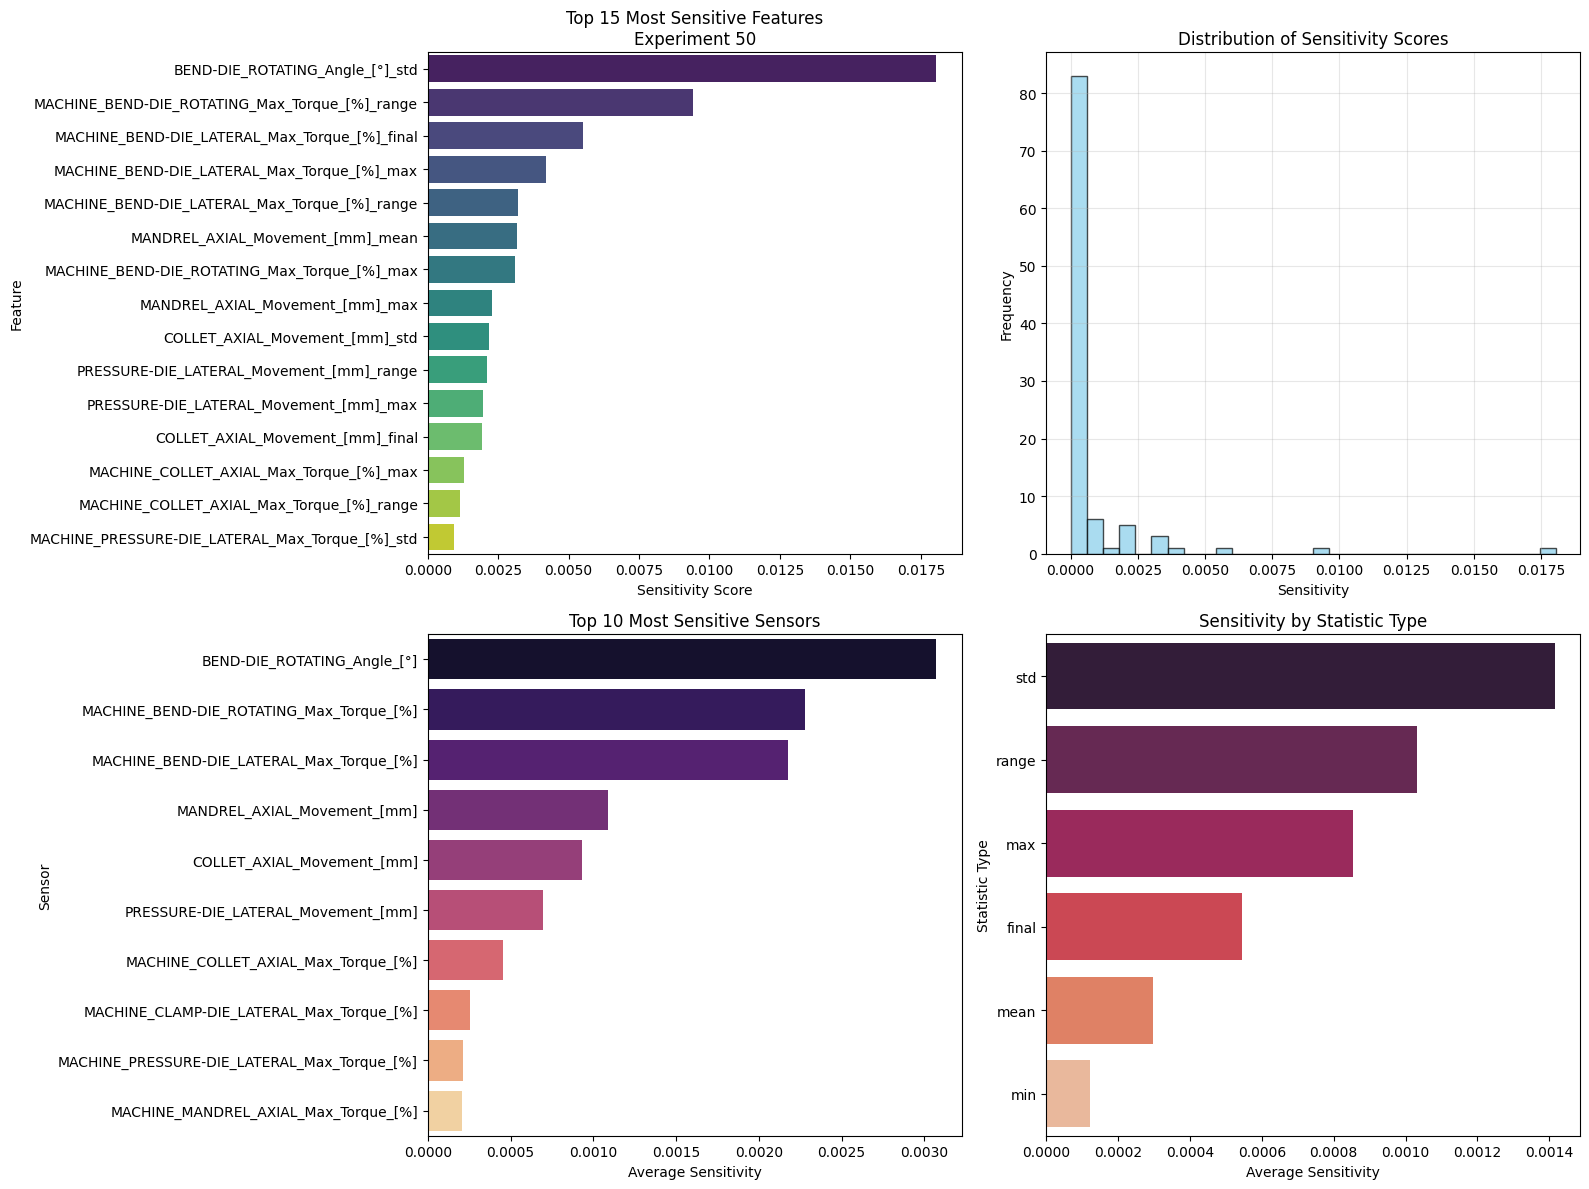


Analysis complete for Experiment 50!

Key Insights:
- Most sensitive feature: BEND-DIE_ROTATING_Angle_[°]_std
- Most sensitive sensor: BEND-DIE_ROTATING_Angle_[°]
- Most informative statistic: std
- Baseline prediction: 0.437685
- Actual value: 0.411007

Global feature importance from trained model:

Top 10 globally important features:
 1. BEND-DIE_ROTATING_Angle_[°]_mean: 0.080981
 2. MANDREL_AXIAL_Movement_[mm]_std: 0.065252
 3. CLAMP-DIE_LATERAL_Movement_[mm]_std: 0.060421
 4. BEND-DIE_LATERAL_Movement_[mm]_mean: 0.059275
 5. BEND-DIE_ROTATING_Angle_[°]_std: 0.053398
 6. PRESSURE-DIE_LATERAL_Movement_[mm]_mean: 0.043693
 7. MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]_std: 0.042077
 8. BEND-DIE_LATERAL_Movement_[mm]_std: 0.039985
 9. CLAMP-DIE_LATERAL_Movement_[mm]_mean: 0.039318
10. COLLET_AXIAL_Movement_[mm]_mean: 0.032536


In [4]:
if 'Experiment_ID' not in targets.columns:
    raise ValueError("Experiment_ID column not found in targets data!")

target_value = targets[targets['Experiment_ID'] == experiment_id].iloc[angle_index][target_name]
experiment_data = features[features['Experiment_ID'] == experiment_id].copy()
experiment_data = experiment_data.sort_index()  # Sort by time

# 5. Prepare the data for analysis - USE FEATURE AGGREGATION INSTEAD
print("\nUsing feature aggregation instead of flattening...")

# Instead of flattening, we'll create summary statistics for each sensor
def create_sensor_summary(exp_data):
    """Create summary statistics for each sensor in an experiment"""
    sensor_data = exp_data.drop('Experiment_ID', axis=1)
    summary = {}
    
    for sensor in sensor_data.columns:
        sensor_values = sensor_data[sensor].values
        summary[f"{sensor}_mean"] = np.mean(sensor_values)
        summary[f"{sensor}_std"] = np.std(sensor_values)
        summary[f"{sensor}_max"] = np.max(sensor_values)
        summary[f"{sensor}_min"] = np.min(sensor_values)
        summary[f"{sensor}_range"] = np.ptp(sensor_values)  # Peak-to-peak
        summary[f"{sensor}_final"] = sensor_values[-1] if len(sensor_values) > 0 else np.nan
    
    return summary

# Create summary for our target experiment
target_summary = create_sensor_summary(experiment_data)
feature_names = list(target_summary.keys())

all_summaries = []
all_experiment_ids = []
all_target_values = []

available_experiment_ids = features['Experiment_ID'].unique()

for exp_id in available_experiment_ids:
    if exp_id == experiment_id:
        continue  # Skip our test experiment
        
    try:
        exp_data = features[features['Experiment_ID'] == exp_id].copy()
        exp_data = exp_data.sort_index()
        
        # Get target value for this experiment
        target_val = targets[(targets['Experiment_ID'] == exp_id)].iloc[angle_index][target_name]
        
        # Create summary features
        exp_summary = create_sensor_summary(exp_data)
        all_summaries.append(exp_summary)
        all_experiment_ids.append(exp_id)
        all_target_values.append(target_val)
        
    except Exception as e:
        print(f"Error processing experiment {exp_id}: {e}")
        continue

# Create training data
X_train = pd.DataFrame(all_summaries)
y_train = pd.Series(all_target_values, index=all_experiment_ids)

# Handle missing values if any
X_train = X_train.fillna(X_train.mean())

# 7. Train the model
model = RandomForestRegressor(
    n_estimators=100,  # Increased for better performance
    random_state=42,
    n_jobs=-1,
    max_features='sqrt'
)
model.fit(X_train, y_train)

# Create a DataFrame for our test experiment
X_test_exp = pd.DataFrame([target_summary])

# Handle missing values
X_test_exp = X_test_exp.fillna(X_train.mean())

# Get baseline prediction
baseline_prediction = model.predict(X_test_exp)[0]
print(f"Baseline prediction: {baseline_prediction:.6f}")
print(f"Actual target value: {target_value:.6f}")
print(f"Prediction error: {abs(baseline_prediction - target_value):.6f}")

# 9. Perturbation Analysis: Modify each feature and measure impact
perturbation_results = []
perturbation_amount = 0.1  # 10% perturbation

for i, feature in enumerate(feature_names):
    if i % 10 == 0:
        print(f"Processing feature {i+1}/{len(feature_names)}...")
    
    # Create perturbed version
    X_perturbed = X_test_exp.copy()
    original_value = X_perturbed[feature].values[0]
    
    # Apply perturbation (10% increase)
    X_perturbed[feature] = original_value * (1 + perturbation_amount)
    
    # Get new prediction
    perturbed_prediction = model.predict(X_perturbed)[0]
    
    # Calculate sensitivity
    sensitivity = abs(perturbed_prediction - baseline_prediction)
    
    perturbation_results.append({
        'feature': feature,
        'original_value': original_value,
        'perturbed_value': original_value * (1 + perturbation_amount),
        'baseline_prediction': baseline_prediction,
        'perturbed_prediction': perturbed_prediction,
        'sensitivity': sensitivity
    })

# Convert to DataFrame
sensitivity_df = pd.DataFrame(perturbation_results)
sensitivity_df = sensitivity_df.sort_values('sensitivity', ascending=False)

print(f"\nTop 10 Most Sensitive Features for Experiment {experiment_id}:")
for i, (_, row) in enumerate(sensitivity_df.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']}: Sensitivity = {row['sensitivity']:.6f}")

# 10. Visualize the results
plt.figure(figsize=(16, 12))

# Top sensitive features
plt.subplot(2, 2, 1)
top_n = min(15, len(sensitivity_df))
top_features = sensitivity_df.head(top_n)
sns.barplot(x='sensitivity', y='feature', data=top_features, palette='viridis')
plt.title(f'Top {top_n} Most Sensitive Features\nExperiment {experiment_id}')
plt.xlabel('Sensitivity Score')
plt.ylabel('Feature')

# Feature values distribution
plt.subplot(2, 2, 2)
plt.hist(sensitivity_df['sensitivity'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Sensitivity Scores')
plt.xlabel('Sensitivity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Parse sensor names from features
sensor_sensitivity = []
for feature in sensitivity_df['feature']:
    # Extract sensor name (remove the statistic suffix)
    sensor_name = '_'.join(feature.split('_')[:-1])
    sensitivity = sensitivity_df[sensitivity_df['feature'] == feature]['sensitivity'].values[0]
    sensor_sensitivity.append({'sensor': sensor_name, 'sensitivity': sensitivity})

sensor_sensitivity_df = pd.DataFrame(sensor_sensitivity)
sensor_importance = sensor_sensitivity_df.groupby('sensor')['sensitivity'].mean().sort_values(ascending=False)

# Most sensitive sensors
plt.subplot(2, 2, 3)
top_sensors = sensor_importance.head(10)
sns.barplot(x=top_sensors.values, y=top_sensors.index, palette='magma')
plt.title('Top 10 Most Sensitive Sensors')
plt.xlabel('Average Sensitivity')
plt.ylabel('Sensor')

# Analyze by statistic type
statistic_importance = []
for feature in sensitivity_df['feature']:
    # Extract statistic type (last part of feature name)
    stat_type = feature.split('_')[-1]
    sensitivity = sensitivity_df[sensitivity_df['feature'] == feature]['sensitivity'].values[0]
    statistic_importance.append({'statistic': stat_type, 'sensitivity': sensitivity})

statistic_df = pd.DataFrame(statistic_importance)
stat_importance = statistic_df.groupby('statistic')['sensitivity'].mean().sort_values(ascending=False)

plt.subplot(2, 2, 4)
sns.barplot(x=stat_importance.values, y=stat_importance.index, palette='rocket')
plt.title('Sensitivity by Statistic Type')
plt.xlabel('Average Sensitivity')
plt.ylabel('Statistic Type')

plt.tight_layout()
plt.savefig(f'sensitivity_analysis_experiment_{experiment_id}.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Save detailed results
sensitivity_df.to_csv(f'sensitivity_analysis_experiment_{experiment_id}.csv', index=False)
sensor_importance.to_csv(f'sensor_sensitivity_experiment_{experiment_id}.csv', header=True)

print(f"\nAnalysis complete for Experiment {experiment_id}!")
print(f"\nKey Insights:")
print(f"- Most sensitive feature: {sensitivity_df.iloc[0]['feature']}")
print(f"- Most sensitive sensor: {sensor_importance.index[0]}")
print(f"- Most informative statistic: {stat_importance.index[0]}")
print(f"- Baseline prediction: {baseline_prediction:.6f}")
print(f"- Actual value: {target_value:.6f}")

# 12. Additional analysis: Global feature importance
print("\nGlobal feature importance from trained model:")
global_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})
global_importance = global_importance.sort_values('importance', ascending=False)

print("\nTop 10 globally important features:")
for i, (_, row) in enumerate(global_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']}: {row['importance']:.6f}")

# Save global importance
global_importance.to_csv(f'global_importance_angle{angle_index}.csv', index=False)


Time windows to analyze:
Window 0: 0.00s - 8.71s
Window 1: 8.71s - 17.42s
Window 2: 17.42s - 26.13s
Window 3: 26.13s - 34.84s
Window 4: 34.84s - 43.55s
Window 5: 43.55s - 52.26s
Window 6: 52.26s - 60.97s
Window 7: 60.97s - 69.68s
Window 8: 69.68s - 78.39s
Window 9: 78.39s - 87.10s

Preparing time interval features for all experiments...
Training data shape: (315, 680)

Training Random Forest model with time interval features...

Analyzing time interval importance...

Most Important Time Intervals (Overall):
Window | Time Range | Total Importance
--------------------------------------------------
     8 |  69.7- 78.4s | 0.185147
     7 |  61.0- 69.7s | 0.184094
     4 |  34.8- 43.6s | 0.183722
     3 |  26.1- 34.8s | 0.158301
     5 |  43.6- 52.3s | 0.139374
     6 |  52.3- 61.0s | 0.077149
     2 |  17.4- 26.1s | 0.030050
     9 |  78.4- 87.1s | 0.020589
     1 |   8.7- 17.4s | 0.011841
     0 |   0.0-  8.7s | 0.009733

Top 10 Sensor-Time Window Combinations:
 1. MACHINE_COLLET_AXIAL_

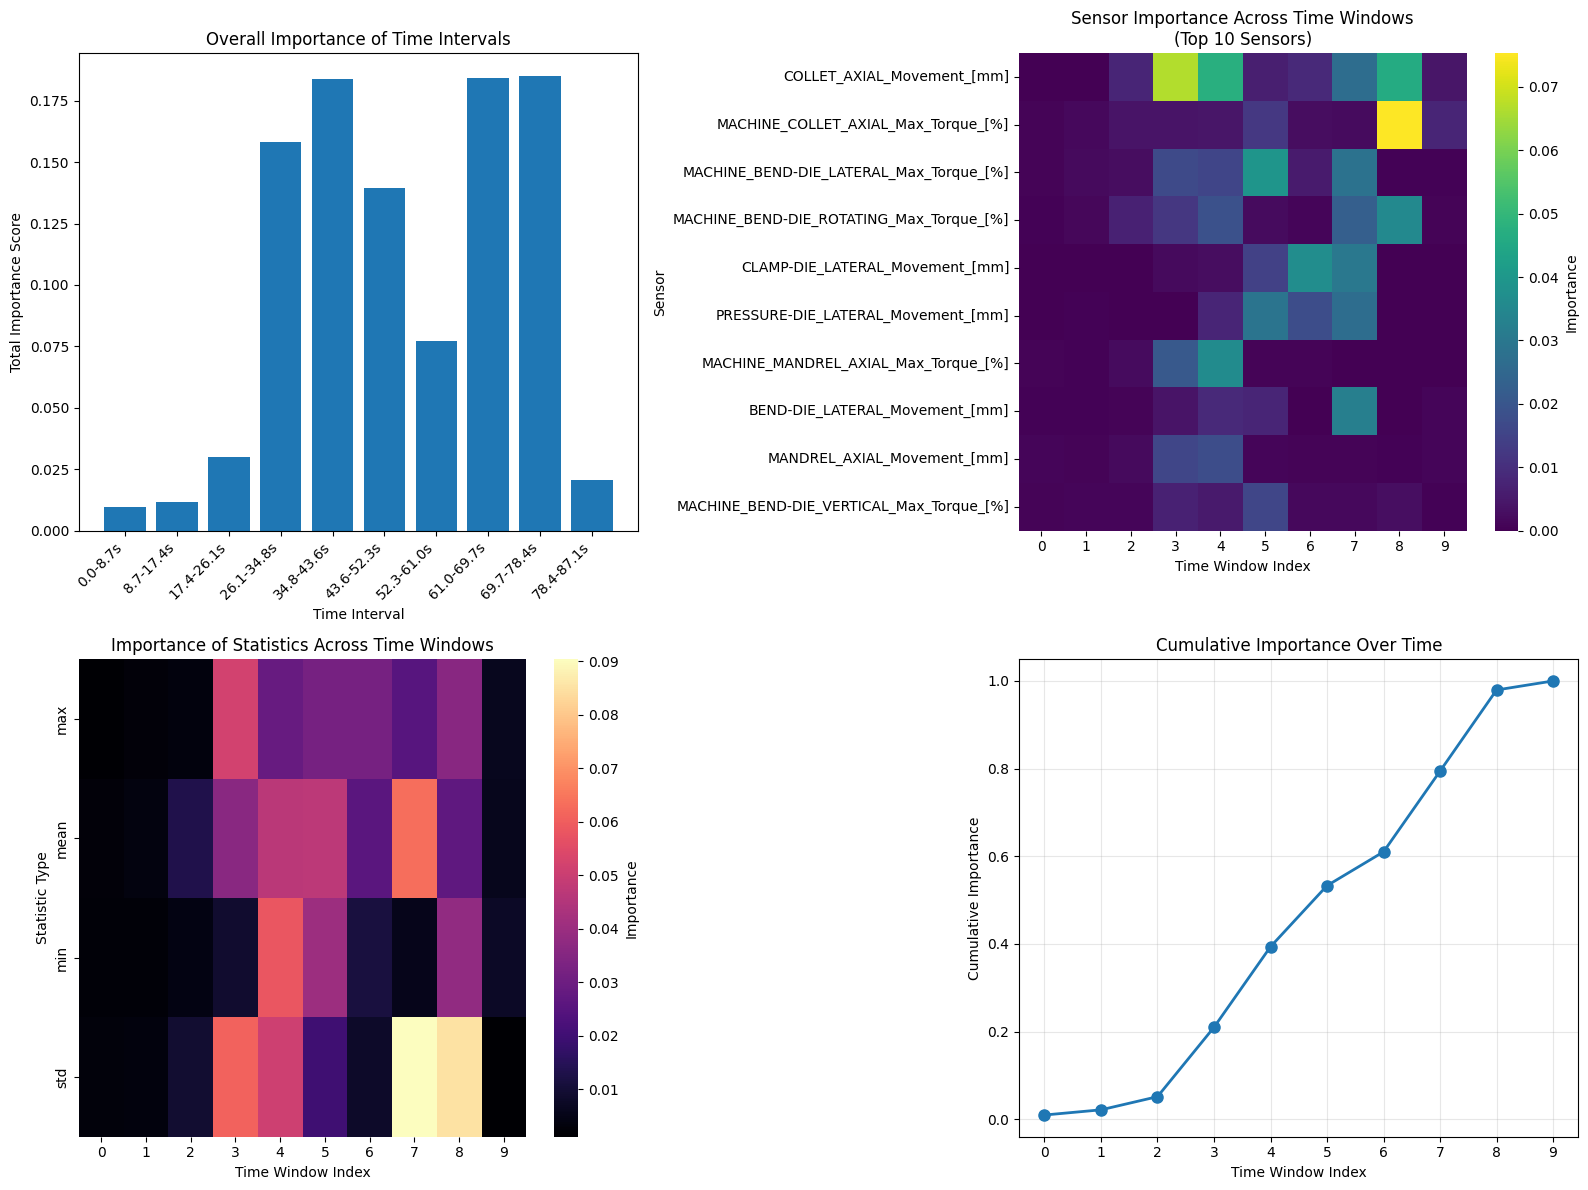


DETAILED ANALYSIS OF MOST IMPORTANT TIME WINDOW:
Window 8: 69.7s - 78.4s
Total Importance: 0.185147

Top Sensors in this Time Window:
 1. MACHINE_COLLET_AXIAL_Max_Torque_[%]: 0.075322
 2. COLLET_AXIAL_Movement_[mm]: 0.046049
 3. MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]: 0.035308
 4. BEND-DIE_ROTATING_Angle_[°]: 0.021789
 5. MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]: 0.002746

Analysis complete!

Key Findings:
- Most important time interval: 69.7s - 78.4s
- Most important sensor in critical window: MACHINE_COLLET_AXIAL_Max_Torque_[%]
- Critical window accounts for 18.5% of total importance


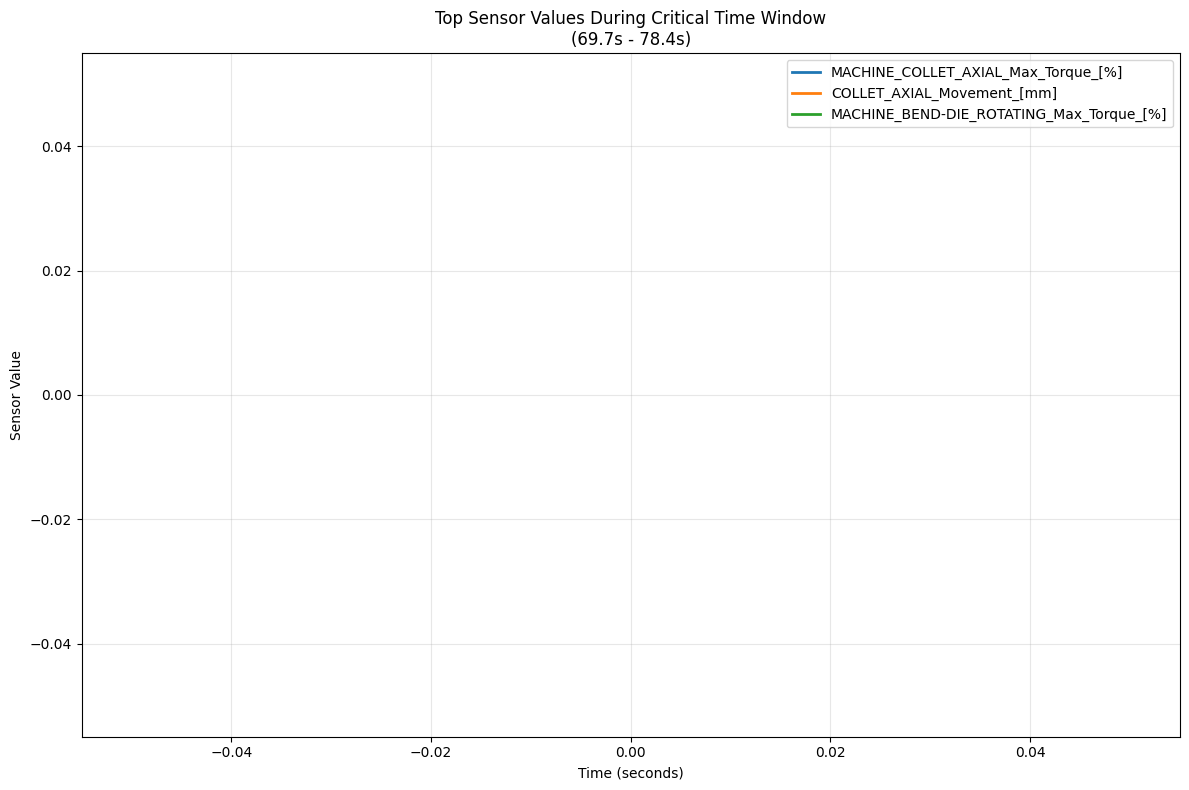

In [5]:
# 3. Create time-based features for each experiment
def create_time_interval_features(exp_data, time_windows):
    """Create features for specific time intervals"""
    sensor_data = exp_data.drop('Experiment_ID', axis=1)
    interval_features = {}
    
    for sensor in sensor_data.columns:
        sensor_values = sensor_data[sensor].values
        time_points = sensor_data.index.values
        
        for i, (start_time, end_time) in enumerate(time_windows):
            # Find indices within the time window
            mask = (time_points >= start_time) & (time_points <= end_time)
            if np.any(mask):
                window_values = sensor_values[mask]
                interval_features[f"{sensor}_mean_{i}"] = np.mean(window_values)
                interval_features[f"{sensor}_std_{i}"] = np.std(window_values)
                interval_features[f"{sensor}_max_{i}"] = np.max(window_values)
                interval_features[f"{sensor}_min_{i}"] = np.min(window_values)
            else:
                # If no data in this window, use NaN (will be filled later)
                interval_features[f"{sensor}_mean_{i}"] = np.nan
                interval_features[f"{sensor}_std_{i}"] = np.nan
                interval_features[f"{sensor}_max_{i}"] = np.nan
                interval_features[f"{sensor}_min_{i}"] = np.nan
    
    return interval_features

# 4. Define time intervals to analyze
# Create 10 equal time intervals across the process duration
def create_time_windows(data, n_windows=10):
    """Create equal time windows across the process"""
    min_time = data.index.min()
    max_time = data.index.max()
    window_size = (max_time - min_time) / n_windows
    
    windows = []
    for i in range(n_windows):
        start = min_time + i * window_size
        end = min_time + (i + 1) * window_size
        windows.append((start, end))
    
    return windows

# Get time windows based on all data
time_windows = create_time_windows(features, n_windows=10)
print(f"\nTime windows to analyze:")
for i, (start, end) in enumerate(time_windows):
    print(f"Window {i}: {start:.2f}s - {end:.2f}s")

# 5. Prepare data for model training
print("\nPreparing time interval features for all experiments...")

all_interval_features = []
all_experiment_ids = []
all_target_values = []

available_experiment_ids = features['Experiment_ID'].unique()

for exp_id in available_experiment_ids:
    try:
        exp_data = features[features['Experiment_ID'] == exp_id].copy()
        exp_data = exp_data.sort_index()
        
        # Get target value for this experiment
        target_val = targets[(targets['Experiment_ID'] == exp_id)].iloc[angle_index][target_name]
        
        # Create time interval features
        exp_features = create_time_interval_features(exp_data, time_windows)
        all_interval_features.append(exp_features)
        all_experiment_ids.append(exp_id)
        all_target_values.append(target_val)
        
    except Exception as e:
        print(f"Error processing experiment {exp_id}: {e}")
        continue

# Create training data
X_train = pd.DataFrame(all_interval_features)
y_train = pd.Series(all_target_values, index=all_experiment_ids)

print(f"Training data shape: {X_train.shape}")

# Handle missing values
X_train = X_train.fillna(X_train.mean())

# 6. Train the Random Forest model
print("\nTraining Random Forest model with time interval features...")
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_features='sqrt'
)
model.fit(X_train, y_train)

# 7. Analyze time interval importance
print("\nAnalyzing time interval importance...")

# Extract feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# Parse time window information from feature names
time_interval_analysis = []

for feature in feature_importances['feature']:
    parts = feature.split('_')
    sensor_name = '_'.join(parts[:-2])  # Everything except the last two parts
    stat_type = parts[-2]  # mean, std, max, min
    window_idx = int(parts[-1])  # Time window index
    
    importance = feature_importances[feature_importances['feature'] == feature]['importance'].values[0]
    start_time, end_time = time_windows[window_idx]
    
    time_interval_analysis.append({
        'sensor': sensor_name,
        'statistic': stat_type,
        'window_index': window_idx,
        'start_time': start_time,
        'end_time': end_time,
        'importance': importance
    })

time_interval_df = pd.DataFrame(time_interval_analysis)

# 8. Analyze which time windows are most important overall
window_importance = time_interval_df.groupby('window_index').agg({
    'importance': 'sum',
    'start_time': 'first',
    'end_time': 'first'
}).sort_values('importance', ascending=False)

print("\nMost Important Time Intervals (Overall):")
print("Window | Time Range | Total Importance")
print("-" * 50)
for idx, row in window_importance.iterrows():
    print(f"{idx:6d} | {row['start_time']:5.1f}-{row['end_time']:5.1f}s | {row['importance']:.6f}")

# 9. Analyze by sensor and time window
sensor_window_importance = time_interval_df.groupby(['sensor', 'window_index']).agg({
    'importance': 'sum',
    'start_time': 'first',
    'end_time': 'first'
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Sensor-Time Window Combinations:")
for i, ((sensor, window_idx), row) in enumerate(sensor_window_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {sensor} | Window {window_idx} ({row['start_time']:.1f}-{row['end_time']:.1f}s): {row['importance']:.6f}")

# 10. Visualize the results
plt.figure(figsize=(16, 12))

# Overall time window importance
plt.subplot(2, 2, 1)
window_importance_sorted = window_importance.sort_index()
window_labels = [f"{row['start_time']:.1f}-{row['end_time']:.1f}s" for _, row in window_importance_sorted.iterrows()]
plt.bar(range(len(window_importance_sorted)), window_importance_sorted['importance'])
plt.title('Overall Importance of Time Intervals')
plt.xlabel('Time Interval')
plt.ylabel('Total Importance Score')
plt.xticks(range(len(window_importance_sorted)), window_labels, rotation=45, ha='right')

# Heatmap of sensor importance across time windows
plt.subplot(2, 2, 2)
heatmap_data = time_interval_df.groupby(['sensor', 'window_index'])['importance'].sum().unstack().fillna(0)
# Get top 10 sensors by total importance
top_sensors = time_interval_df.groupby('sensor')['importance'].sum().sort_values(ascending=False).head(10).index
heatmap_data_top = heatmap_data.loc[top_sensors]

sns.heatmap(heatmap_data_top, cmap='viridis', cbar_kws={'label': 'Importance'})
plt.title('Sensor Importance Across Time Windows\n(Top 10 Sensors)')
plt.xlabel('Time Window Index')
plt.ylabel('Sensor')
plt.tight_layout()

# Importance by statistic type across time
plt.subplot(2, 2, 3)
stat_time_importance = time_interval_df.groupby(['statistic', 'window_index'])['importance'].sum().unstack().fillna(0)
sns.heatmap(stat_time_importance, cmap='magma', cbar_kws={'label': 'Importance'})
plt.title('Importance of Statistics Across Time Windows')
plt.xlabel('Time Window Index')
plt.ylabel('Statistic Type')

# Cumulative importance over time
plt.subplot(2, 2, 4)
cumulative_importance = []
current_importance = 0
for window_idx in sorted(time_interval_df['window_index'].unique()):
    window_imp = time_interval_df[time_interval_df['window_index'] == window_idx]['importance'].sum()
    current_importance += window_imp
    cumulative_importance.append(current_importance)

plt.plot(range(len(cumulative_importance)), cumulative_importance, 'o-', linewidth=2, markersize=8)
plt.title('Cumulative Importance Over Time')
plt.xlabel('Time Window Index')
plt.ylabel('Cumulative Importance')
plt.grid(True, alpha=0.3)
plt.xticks(range(len(time_windows)), [f"{i}" for i in range(len(time_windows))])

plt.tight_layout()
plt.savefig(f'time_interval_importance_angle{angle_index}.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Detailed analysis of the most important time window
most_important_window = window_importance.index[0]
most_important_start = window_importance.loc[most_important_window, 'start_time']
most_important_end = window_importance.loc[most_important_window, 'end_time']

print(f"\nDETAILED ANALYSIS OF MOST IMPORTANT TIME WINDOW:")
print(f"Window {most_important_window}: {most_important_start:.1f}s - {most_important_end:.1f}s")
print(f"Total Importance: {window_importance.loc[most_important_window, 'importance']:.6f}")

# Get top sensors in this window
window_sensors = time_interval_df[time_interval_df['window_index'] == most_important_window]
window_sensors = window_sensors.groupby('sensor')['importance'].sum().sort_values(ascending=False)

print(f"\nTop Sensors in this Time Window:")
for i, (sensor, imp) in enumerate(window_sensors.head(5).items(), 1):
    print(f"{i:2d}. {sensor}: {imp:.6f}")

# 12. Save results
window_importance.to_csv(f'time_window_importance_angle{angle_index}.csv')
time_interval_df.to_csv(f'detailed_time_interval_analysis_angle{angle_index}.csv', index=False)

print(f"\nAnalysis complete!")
print(f"\nKey Findings:")
print(f"- Most important time interval: {most_important_start:.1f}s - {most_important_end:.1f}s")
print(f"- Most important sensor in critical window: {window_sensors.index[0]}")
print(f"- Critical window accounts for {window_importance.iloc[0]['importance']/window_importance['importance'].sum()*100:.1f}% of total importance")

# 13. Additional: Show actual sensor values during critical time window
critical_exp_id = available_experiment_ids[0]  # Use first experiment as example
critical_exp_data = features[features['Experiment_ID'] == critical_exp_id].copy()
critical_exp_data = critical_exp_data.sort_index()

# Filter to critical time window
critical_data = critical_exp_data[(critical_exp_data.index >= most_important_start) & 
                                 (critical_exp_data.index <= most_important_end)]

# Plot top sensors during critical window
top_sensor_names = window_sensors.head(3).index.tolist()
plt.figure(figsize=(12, 8))
for sensor in top_sensor_names:
    if sensor in critical_data.columns:
        plt.plot(critical_data.index, critical_data[sensor], label=sensor, linewidth=2)

plt.title(f'Top Sensor Values During Critical Time Window\n({most_important_start:.1f}s - {most_important_end:.1f}s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'critical_window_sensor_values_angle{angle_index}.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================
# LSTM Model Definition
# =========================
class LSTMModel(nn.Module):
    def __init__(self, input_size=19, hidden_size=64, num_layers=1, output_size=5, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = torch.mean(lstm_out, dim=1)  # mean pooling over time
        out = self.dropout(out)
        out = self.fc(out)
        return out


# =========================
# Training Method
# =========================
def train_model(model, X, y, epochs=1500, lr=0.001, print_every=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.8f}")

    print("Training complete.")
    return model


# =========================
# Evaluation Method
# =========================
def evaluate_model(model, X, y):
    model.eval()
    criterion = nn.MSELoss()
    with torch.no_grad():
        output = model(X)
        loss = criterion(output, y)
    print(f"Final Loss: {loss.item():.8f}")
    print(f"Predicted: {output.squeeze().numpy()}")
    print(f"Target: {y.squeeze().numpy()}")
    return output, loss.item()


# =========================
# Sliding Window Importance
# =========================
def sliding_window_importance(model, X_sample, y_target=None,target_id=1, window_size=50, stride=25):
    """
    Compute importance of sequence windows by masking them and measuring change in prediction.
    Returns a list of tuples: (start, end, importance_score)
    """
    model.eval()
    seq_len, num_features = X_sample.shape
    X_sample = X_sample.clone()
    
    with torch.no_grad():
        baseline_pred = model(X_sample.unsqueeze(0))

    if y_target is not None:
        print(f"Baseline Prediction: {baseline_pred}\nTarget: {y_target}")

    importance_scores = []
    for start in range(0, seq_len - window_size + 1, stride):
        end = start + window_size
        X_masked = X_sample.clone()
        X_masked[start:end, :] = 0.0
        with torch.no_grad():
            masked_pred = model(X_masked.unsqueeze(0))
        score = torch.norm(baseline_pred - masked_pred).item()
        importance_scores.append((start, end, score))
    
    return importance_scores


# =========================
# Visualization Method
# =========================
import matplotlib.pyplot as plt
import numpy as np
def plot_importance(X_sample, scores, targets,x_value, top_n=3):
    # Ensure X_sample is a tensor
    if isinstance(X_sample, np.ndarray):
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
    elif isinstance(X_sample, pd.DataFrame):
        X_sample = torch.tensor(X_sample.values, dtype=torch.float32)
    X_sample = X_sample.detach()
    
    num_features = X_sample.shape[1]

    # Get top N windows
    top_indices = np.argsort([sc for _, _, sc in scores])[-top_n:][::-1]
    top_windows = [scores[i] for i in top_indices]

        # Create subplots with independent x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Colors for features
    colors = plt.cm.tab10(np.linspace(0, 1, min(10, num_features)))

    # Plot all features (normalized + offset)
    for i in range(num_features):
        data = X_sample[:, i].numpy()
        norm_data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
        ax1.plot(norm_data + i, color=colors[i % len(colors)], linewidth=1.5,
                 label=f'Feature {i}', alpha=0.8)

    # Highlight top windows on features plot
    window_colors = ['red', 'orange', 'yellow']
    for j, (start, end, score) in enumerate(top_windows):
        ax1.axvspan(start, end, alpha=0.3, color=window_colors[j % len(window_colors)],
                    label=f'Window [{start}-{end}]' if j == 0 else "")
        mid = (start + end) // 2
        ax1.annotate(f'Score: {score:.3f}', xy=(mid, ax1.get_ylim()[1] * 0.95),
                     ha='center', fontweight='bold', fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor=window_colors[j % len(window_colors)], alpha=0.7))

    ax1.set_ylabel('Feature Value (Normalized + Offset)')
    ax1.set_title('All Features with Important Windows Highlighted')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot targets with their own x-axis
    
    ax2.plot(targets, marker='o', label=targets.columns)
    ax2.axvspan(x_value, x_value+1, alpha=0.3)
    ax2.set_xlabel('Time Step (Independent)')
    ax2.set_ylabel('Target Value')
    ax2.set_title('Target Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print top windows
    print("\nTop Important Windows:")
    for i, (start, end, score) in enumerate(top_windows):
        print(f"Window {i+1}: Time steps {start}-{end}, Importance Score: {score:.6f}")


In [7]:
target_id = 6
# Convert to tensors
X = torch.tensor(features.values, dtype=torch.float32)   # (806, 19)
X = X.unsqueeze(0)[0,:,1:]  # add batch dim -> (1, 806, 19)

y = torch.tensor(targets.iloc[target_id].values, dtype=torch.float32)  # (4,)
y = y.unsqueeze(0)[:,2:]  # add batch dim -> (1, 4)

# Initialize model
model = LSTMModel(input_size=17, hidden_size=64, num_layers=3, output_size=4)


# Train model
train_model(model, X, y, epochs=100,lr=1e-4)


# Evaluate model
evaluate_model(model, X, y)

# Compute importance
scores = sliding_window_importance(model, X[0], y_target=y,target_id=target_id,window_size=50,stride=50)

# Plot results
plot_importance(X[0], scores, top_n=2, targets=targets, x_value=target_id)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x490868 and 64x4)